In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [42]:
df = pd.read_csv("C:/Games/Desktop/Documents/Projects_Sem4/ML/dataset/video_features.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (146, 6)
   duration_sec  bitrate  width  height  file_size_bytes  label
0             0        0      0       0         22377498      0
1             0        0      0       0         19435968      0
2             0        0      0       0          2945077      0
3             0        0      0       0         14660163      0
4             0        0      0       0         18471928      0


In [ ]:
X = df[["file_size_bytes"]]   
y = df["label"]               

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 116
Testing Samples: 30


In [44]:
#A1 – Linear Regression
reg = LinearRegression()
reg.fit(X_train, y_train)

y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

print("Coefficient:", reg.coef_)
print("Intercept:", reg.intercept_)

Coefficient: [-8.65940059e-10]
Intercept: 0.36568943445514257


In [45]:
#A2 – MSE, RMSE, MAPE, R2
# TRAIN METRICS
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)
train_mape = np.mean(np.abs((y_train - y_train_pred) / (y_train + 1e-6))) * 100

# TEST METRICS
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1e-6))) * 100

print("===== TRAIN METRICS =====")
print("MSE:", train_mse)
print("RMSE:", train_rmse)
print("MAPE:", train_mape)
print("R2:", train_r2)

print("\n===== TEST METRICS =====")
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("MAPE:", test_mape)
print("R2:", test_r2)

===== TRAIN METRICS =====
MSE: 0.2256234706715204
RMSE: 0.47499839017781986
MAPE: 22562369.629476555
R2: 0.0013192692907965098

===== TEST METRICS =====
MSE: 0.20359443321261497
RMSE: 0.4512143982771549
MAPE: 25286105.06037138
R2: -0.04110789710996299


In [46]:
#A3 – Multiple Features
reg_all = LinearRegression()
reg_all.fit(X_train, y_train)

y_train_pred_all = reg_all.predict(X_train)
y_test_pred_all = reg_all.predict(X_test)

print("A3 R2 (Train):", r2_score(y_train, y_train_pred_all))
print("A3 R2 (Test):", r2_score(y_test, y_test_pred_all))



A3 R2 (Train): 0.0013192692907965098
A3 R2 (Test): -0.04110789710996299


In [47]:
#A4 – KMeans Clustering
X_cluster = df[["file_size_bytes"]]

kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
kmeans.fit(X_cluster)

print("Cluster Labels:")
print(kmeans.labels_)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Labels:
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
Cluster Centers:
[[16131825.94827587]
 [56359262.33333334]]


c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [48]:
#A5 – Clustering Scores
labels = kmeans.labels_

sil_score = silhouette_score(X_cluster, labels)
ch_score = calinski_harabasz_score(X_cluster, labels)
db_score = davies_bouldin_score(X_cluster, labels)

print("Silhouette Score:", sil_score)
print("Calinski-Harabasz Score:", ch_score)
print("Davies-Bouldin Index:", db_score)


Silhouette Score: 0.6700504535614447
Calinski-Harabasz Score: 306.8752576985173
Davies-Bouldin Index: 0.5047673591420071


c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

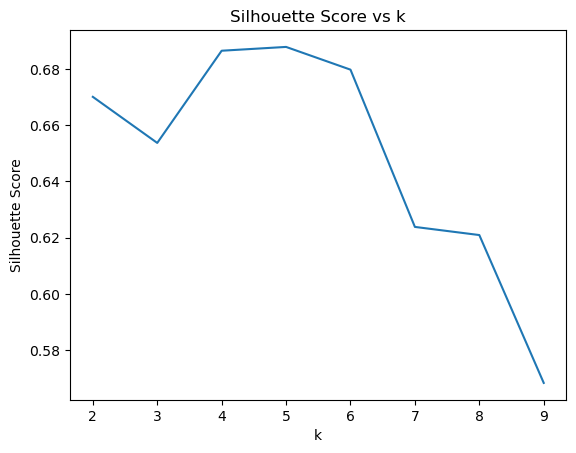

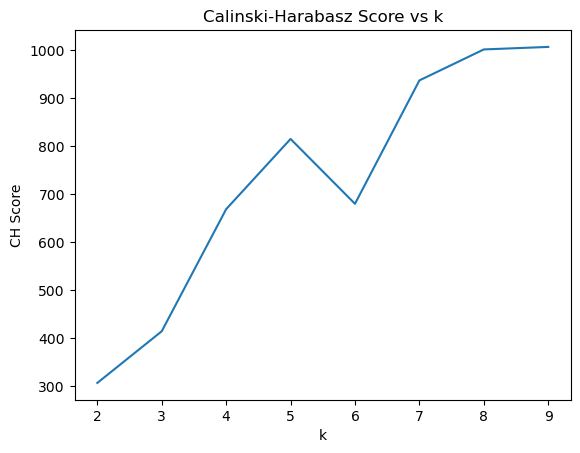

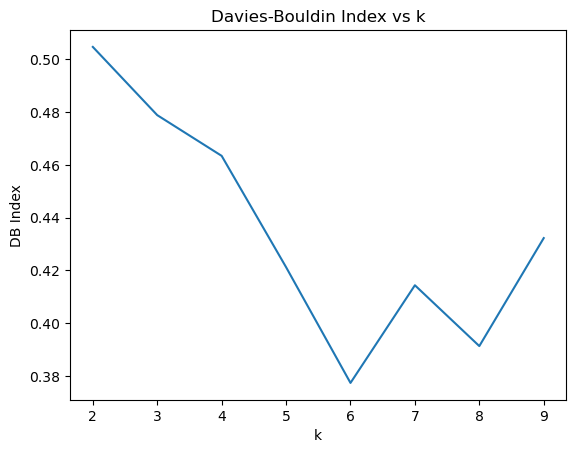

In [ ]:
# A6 

k_values = range(2, 10)

sil_scores = []
ch_scores = []
db_scores = []

X_cluster = df[["file_size_bytes"]]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_cluster)
    labels = kmeans.labels_

    sil_scores.append(silhouette_score(X_cluster, labels))
    ch_scores.append(calinski_harabasz_score(X_cluster, labels))
    db_scores.append(davies_bouldin_score(X_cluster, labels))


# Plot 1: Silhouette Score
plt.figure()
plt.plot(k_values, sil_scores)
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()


# Plot 2: Calinski-Harabasz Score
plt.figure()
plt.plot(k_values, ch_scores)
plt.title("Calinski-Harabasz Score vs k")
plt.xlabel("k")
plt.ylabel("CH Score")
plt.show()


#  Plot 3: Davies-Bouldin Index
plt.figure()
plt.plot(k_values, db_scores)
plt.title("Davies-Bouldin Index vs k")
plt.xlabel("k")
plt.ylabel("DB Index")
plt.show()

c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

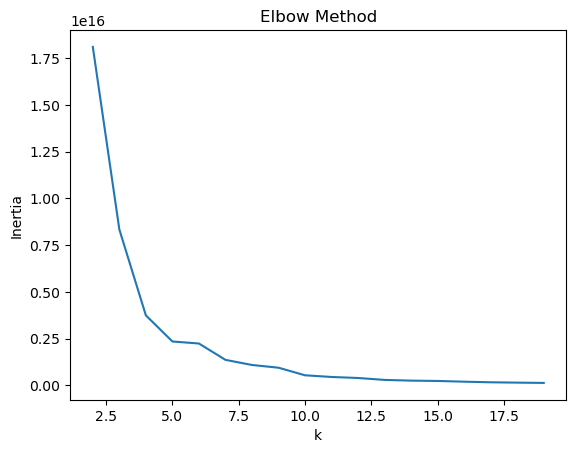

In [50]:
#A7 – Elbow Plot
k_values = range(2, 20)
distortions = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_cluster)
    distortions.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, distortions)
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()